# How much time does Homo sapiens have left? A synthesis of outside-view and inside-view estimates

## Abstract

This notebook combines three prior threads of work -- a Bayesian model of the
total number of humans ever born (`human_population_bayesian_model_v4.ipynb`),
an empirical survival-curve prior for mammalian species duration built from
Paleobiology Database fossil data (`mammal_species_survival_v1.ipynb`), and a
review of the anthropic "Doomsday argument" literature -- to produce estimates
of how much longer *Homo sapiens* is likely to persist before extinction or
transformation into a different species, under the explicit assumption that no
sudden catastrophe (world war, abrupt climate collapse, etc.) intervenes, and
that the present moment is not a privileged position in the species' total
history.

We compute this three independent ways: (A) an **outside-view** calculation
that treats the two mammalian species-duration priors as a reference-class
survival function and asks for the *residual* (remaining) life of a lineage
that has already survived ~195,000 years; (B) an **inside-view**, time-based
self-sampling calculation following Gott's (1993) "delta-t" argument; and (C)
an **inside-view**, birth-rank-based self-sampling calculation following the
classic Carter-Leslie Doomsday argument, using this project's own posterior
distribution for the total number of humans born so far.

The three methods disagree by several orders of magnitude -- outside-view and
Gott's time-based argument both suggest remaining durations on the order of
hundreds of thousands to a few million years, while the birth-rank argument,
combined with present-day demographic rates, suggests remaining durations on
the order of centuries to tens of thousands of years. We treat this
disagreement as substantively informative rather than as a discrepancy to be
resolved away, and discuss why the three methods answer different, only
partially-overlapping questions. A full pros/cons discussion and a
conclusions section synthesizing all of the above are provided at the end.

**This notebook is self-contained**: it reloads and reprocesses the same raw
PBDB extract used previously to refit the two mammalian survival priors
in-place, and it imports (with citation) the key summary numbers from the
population model rather than requiring that notebook to be re-run. Full
diagnostic detail on data quality and modeling caveats for each upstream
piece lives in the companion notebooks referenced throughout and in
Section 9.


## 1. Introduction and framing

**The question.** How much longer will *Homo sapiens* persist, before either
extinction or evolutionary transformation into a different species -- assuming
no sudden, discrete catastrophe, and assuming the present moment is not a
statistically special point in the species' timeline (neither near the
beginning nor deliberately near the end)?

**Why there are (at least) two structurally different ways to answer this.**

- **The outside view** asks: what does the historical record of *comparable
  cases* (other mammal species) suggest about how long lineages like this one
  tend to last, and where does our current age put us within that
  distribution? This is a reference-class / base-rate argument, and it is
  what Part A of this notebook computes, using the two priors built in
  `mammal_species_survival_v1.ipynb`.

- **The inside view** asks: given only the fact of *our own position* within
  the species' history (either how much time has elapsed, or how many humans
  have already been born), what does a self-sampling argument imply about the
  total extent of that history? This is the family of arguments known as the
  **Doomsday argument**, originated by Brandon Carter and developed by John
  Leslie (the birth-rank version) and J. Richard Gott (the elapsed-time
  version). Parts B and C of this notebook compute both variants.

These are genuinely different arguments with different assumptions, and there
is real, unresolved philosophical disagreement about which (if either) is the
correct way to reason under anthropic uncertainty -- see Bostrom (2002) for a
book-length treatment of the difficulties involved (the *self-sampling
assumption* vs. the *self-indication assumption*, and the "presumptuous
philosopher" problem). We do not attempt to resolve that disagreement here;
instead we compute all three estimates transparently and let their
(dis)agreement inform the discussion.

**What this notebook does not attempt.** It does not model sudden catastrophic
risks (nuclear war, engineered pandemics, abrupt runaway climate change,
asteroid impact, etc.), which several published existential-risk estimates
(e.g. Ord 2020) treat as the dominant source of near-term risk and which are
explicitly excluded by the question as posed. It also does not build a
population-genetics model of speciation feasibility; "transformation into a
different species" is treated as an alternative, similarly-irreversible exit
event alongside extinction, consistent with how the fossil record itself
usually cannot cleanly distinguish true extinction from anagenetic transition
into a recognized descendant taxon (a point already noted as a data-quality
caveat in `mammal_species_survival_v1.ipynb`, Section 8).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, integrate, optimize
from lifelines import KaplanMeierFitter, LogLogisticFitter

RNG_SEED = 20260829
rng = np.random.default_rng(RNG_SEED)
pd.set_option("display.max_columns", 20)
print("Setup OK")


Setup OK


## 2. Part A -- Outside view: residual life under the mammalian species-duration priors

### 2.1 Recreating the two priors

This condenses the pipeline from `mammal_species_survival_v1.ipynb` (data
filtering, deduplication, `dur_max` duration definition, censoring treatment)
down to what's needed to refit the two priors. See that notebook for the full
derivation, the stratigraphic-resolution diagnostic, and data-quality
discussion -- it is not repeated here.


In [2]:
RAW_PATH = "pbdb_data.csv"
df_raw = pd.read_csv(RAW_PATH, skiprows=16, low_memory=False)

species = df_raw[(df_raw["accepted_rank"] == "species") & (df_raw["n_occs"] > 0)].copy()
dedup = species.drop_duplicates(subset="accepted_no", keep="first").copy()
dedup["dur_max"] = dedup["firstapp_max_ma"] - dedup["lastapp_min_ma"]

data = dedup[dedup["is_extant"].isin(["extinct", "extant"])].copy()
data["event_observed"] = (data["is_extant"] == "extinct").astype(int)
data["duration"] = data["dur_max"]

T, E = data["duration"].values, data["event_observed"].values
print(f"Species used: {len(data):,} ({(E==1).sum():,} extinct, {(E==0).sum():,} extant-censored)")

kmf = KaplanMeierFitter().fit(T, event_observed=E, label="Kaplan-Meier (empirical)")
llf = LogLogisticFitter().fit(T, event_observed=E, label="Log-logistic (parametric)")
ll_dist = stats.fisk(c=llf.beta_, scale=llf.alpha_)  # lifelines' log-logistic == scipy's fisk

print(f"\nLog-logistic fit: alpha (scale) = {llf.alpha_:.4f} Myr, beta (shape) = {llf.beta_:.4f}")


Species used: 12,469 (11,448 extinct, 1,021 extant-censored)

Log-logistic fit: alpha (scale) = 5.2534 Myr, beta (shape) = 2.2699


### 2.2 How much time has *Homo sapiens* already survived?

We take **t0 = 195,000 years (0.195 Myr)** as the primary estimate, matching
the founding-date convention already used in `human_population_bayesian_model_v4.ipynb`
(190,000 years before present plus a small stochastic offset). As a robustness
check we also show t0 = 315,000 years, matching the redated Jebel Irhoud fossils
(Hublin et al. 2017), the oldest currently accepted anatomically-modern-human
material. Because both values are tiny relative to the bulk of the
species-duration distributions fitted above (median duration is several
million years), the choice between them will turn out not to matter much --
which is itself a finding worth stating plainly rather than glossing over.


In [3]:
T0_PRIMARY = 0.195   # Myr
T0_ALT     = 0.315   # Myr, Jebel Irhoud-based robustness check

sf = kmf.survival_function_.reset_index()
sf.columns = ["t", "S"]

def S_km(t):
    return np.interp(t, sf["t"], sf["S"], left=1.0, right=0.0)

for t0, label in [(T0_PRIMARY, "primary"), (T0_ALT, "robustness check")]:
    print(f"t0 = {t0*1e6:,.0f} yr ({label}):")
    print(f"  KM S(t0)           = {S_km(t0):.6f}")
    print(f"  Log-logistic S(t0) = {ll_dist.sf(t0):.6f}")
    print( "  (both very close to 1 -> H. sapiens is very young relative to typical species durations)")
    print()


t0 = 195,000 yr (primary):
  KM S(t0)           = 0.991538
  Log-logistic S(t0) = 0.999434
  (both very close to 1 -> H. sapiens is very young relative to typical species durations)

t0 = 315,000 yr (robustness check):
  KM S(t0)           = 0.990034
  Log-logistic S(t0) = 0.998320
  (both very close to 1 -> H. sapiens is very young relative to typical species durations)



### 2.3 Residual-life calculation

Given survival to age $t_0$, the conditional survival function for
additional time $s$ is $S(t_0+s \mid T>t_0) = S(t_0+s)/S(t_0)$. We compute the
median and mean residual life under both priors, using $t_0$ = 0.195 Myr.


In [4]:
def residual_median_km(t0):
    S0 = S_km(t0)
    target = 0.5 * S0
    mask = sf["t"].values >= t0
    idx = np.searchsorted(-sf["S"].values[mask], -target)
    return sf["t"].values[mask][idx] - t0

def residual_mean_km(t0):
    S0 = S_km(t0)
    mask = sf["t"].values >= t0
    t_arr = np.concatenate([[t0], sf["t"].values[mask]])
    S_arr = np.concatenate([[S0], sf["S"].values[mask]])
    return np.trapezoid(S_arr, t_arr) / S0

def residual_median_ll(t0):
    S0 = ll_dist.sf(t0)
    return optimize.brentq(lambda s: ll_dist.sf(t0+s)/S0 - 0.5, 0, 500)

def residual_mean_ll(t0):
    S0 = ll_dist.sf(t0)
    return integrate.quad(lambda t: ll_dist.sf(t), t0, np.inf)[0] / S0

results_A = pd.DataFrame([
    dict(prior="Kaplan-Meier (empirical)", t0_yr=T0_PRIMARY*1e6,
         median_remaining_yr=residual_median_km(T0_PRIMARY)*1e6,
         mean_remaining_yr=residual_mean_km(T0_PRIMARY)*1e6),
    dict(prior="Log-logistic (parametric)", t0_yr=T0_PRIMARY*1e6,
         median_remaining_yr=residual_median_ll(T0_PRIMARY)*1e6,
         mean_remaining_yr=residual_mean_ll(T0_PRIMARY)*1e6),
    dict(prior="Kaplan-Meier (empirical)", t0_yr=T0_ALT*1e6,
         median_remaining_yr=residual_median_km(T0_ALT)*1e6,
         mean_remaining_yr=residual_mean_km(T0_ALT)*1e6),
    dict(prior="Log-logistic (parametric)", t0_yr=T0_ALT*1e6,
         median_remaining_yr=residual_median_ll(T0_ALT)*1e6,
         mean_remaining_yr=residual_mean_ll(T0_ALT)*1e6),
])
with pd.option_context("display.float_format", lambda x: f"{x:,.0f}"):
    print(results_A.to_string(index=False))


                    prior   t0_yr  median_remaining_yr  mean_remaining_yr
 Kaplan-Meier (empirical) 195,000            5,005,000          6,540,559
Log-logistic (parametric) 195,000            5,060,978          7,208,664
 Kaplan-Meier (empirical) 315,000            4,885,000          6,430,429
Log-logistic (parametric) 315,000            4,946,137          7,096,631


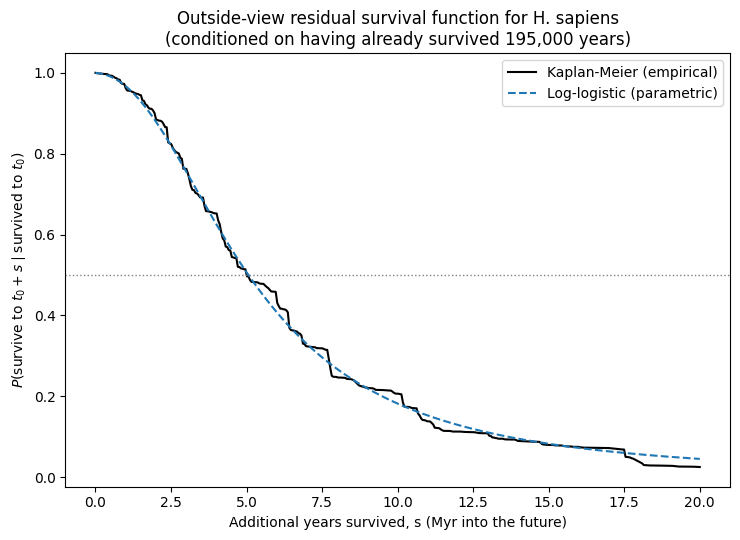

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
s_grid = np.linspace(0, 20, 400)  # Myr into the future
S0_km, S0_ll = S_km(T0_PRIMARY), ll_dist.sf(T0_PRIMARY)
ax.plot(s_grid, [S_km(T0_PRIMARY+s)/S0_km for s in s_grid], label="Kaplan-Meier (empirical)", color="black")
ax.plot(s_grid, ll_dist.sf(T0_PRIMARY+s_grid)/S0_ll, label="Log-logistic (parametric)", linestyle="--")
ax.axhline(0.5, color="gray", linestyle=":", linewidth=1)
ax.set_xlabel("Additional years survived, s (Myr into the future)")
ax.set_ylabel(r"$P(\mathrm{survive\ to}\ t_0+s \mid \mathrm{survived\ to}\ t_0)$")
ax.set_title(f"Outside-view residual survival function for H. sapiens\n"
             f"(conditioned on having already survived {T0_PRIMARY*1e6:,.0f} years)")
ax.legend()
plt.tight_layout()
plt.savefig("fig1_residual_survival.png", dpi=150)
plt.show()


## 3. Part B -- Inside view: Gott's time-based "delta-t" argument

Gott (1993) proposed that, absent other information, our position in time
within an ongoing phenomenon's total duration should be treated as a
uniformly random draw. If a phenomenon has already lasted $t_{\text{past}}$,
then a confidence-$C$ interval on its *remaining* duration $t_{\text{future}}$
is:

$$
t_{\text{past}} \cdot \frac{f}{1-f} \;<\; t_{\text{future}} \;<\; t_{\text{past}} \cdot \frac{1-f}{f}, \qquad f = \frac{1-C}{2}
$$

This requires only $t_{\text{past}}$ -- no reference-class data and no
population model. Gott applied this exact argument to the human species in
his original paper, using an elapsed time of roughly 200,000 years.


In [6]:
t_past_yr = 195_000

def gott_interval(t_past, C):
    f = (1-C)/2
    return t_past*f/(1-f), t_past*(1-f)/f

rows = []
for C in [0.50, 0.80, 0.95, 0.99]:
    lo, hi = gott_interval(t_past_yr, C)
    rows.append(dict(confidence=C, lower_yr=lo, upper_yr=hi))
gott_df = pd.DataFrame(rows)
print(gott_df.to_string(index=False, formatters={
    "confidence": "{:.2f}".format, "lower_yr": "{:,.0f}".format, "upper_yr": "{:,.0f}".format
}))


confidence lower_yr   upper_yr
      0.50   65,000    585,000
      0.80   21,667  1,755,000
      0.95    5,000  7,605,000
      0.99      980 38,805,000


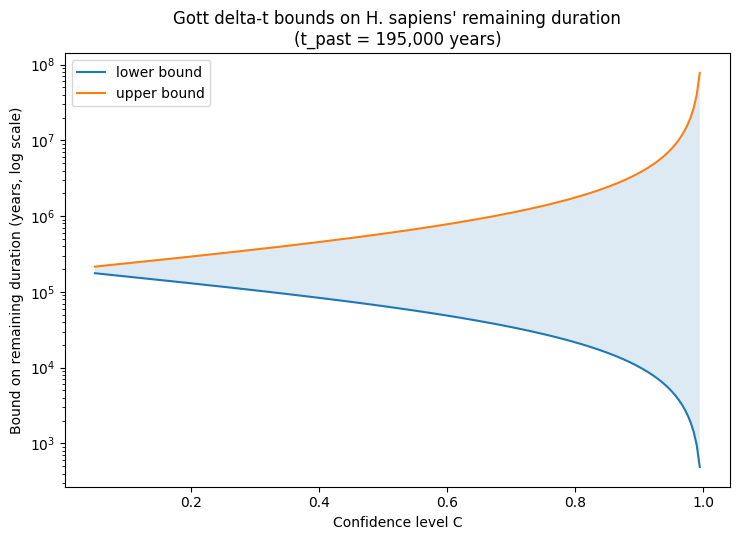

In [7]:
C_grid = np.linspace(0.05, 0.995, 200)
los, his = zip(*[gott_interval(t_past_yr, C) for C in C_grid])

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.plot(C_grid, los, label="lower bound")
ax.plot(C_grid, his, label="upper bound")
ax.fill_between(C_grid, los, his, alpha=0.15)
ax.set_yscale("log")
ax.set_xlabel("Confidence level C")
ax.set_ylabel("Bound on remaining duration (years, log scale)")
ax.set_title(f"Gott delta-t bounds on H. sapiens' remaining duration\n(t_past = {t_past_yr:,} years)")
ax.legend()
plt.tight_layout()
plt.savefig("fig2_gott_bounds.png", dpi=150)
plt.show()


## 4. Part C -- Inside view: Carter-Leslie rank-based Doomsday argument

This variant uses our position not in *time*, but in the *cumulative count of
births* -- exactly the quantity computed by
`human_population_bayesian_model_v4.ipynb`. If your birth rank $k$ (here,
total humans born so far) is a uniform random draw from $1$ to the eventual
total $N$, and we place the (scale-invariant) Jeffreys prior $\pi(N)\propto 1/N$
over $N$, the posterior is:

$$
P(N \mid k) = \frac{k}{N^2}, \qquad N \ge k
$$

which has the well-known closed-form results: posterior median
$\hat N_{50} = 2k$, and a 95% credible interval of
$[\,k/0.975,\; k/0.025\,] = [\,1.026k,\; 40k\,]$.

### 4.1 Importing the population-model posterior

We import summary statistics directly from
`human_population_bayesian_model_v4.ipynb` (its "hybrid" model, the
notebook's canonical choice) rather than re-running PyMC sampling here:
**mean 79.4 billion, 95% CI [70.5B, 89.4B]** total humans ever born as of
2024. We approximate this posterior as Normal for the purpose of propagating
its (comparatively modest) uncertainty alongside the much larger Doomsday
multiplier below -- this is an approximation made for tractability, not a
re-derivation; see that notebook for the actual posterior shape.


In [8]:
N_PAST_MEAN = 79.4e9
N_PAST_SD   = (89.4e9 - 70.5e9) / (2*1.96)   # back out an approx SD from the reported 95% CI
print(f"N_past ~ Normal({N_PAST_MEAN:.3e}, {N_PAST_SD:.3e})")

N_MC = 2_000_000
N_past_draws = np.clip(rng.normal(N_PAST_MEAN, N_PAST_SD, N_MC), 1e9, None)
U = rng.uniform(0, 1, N_MC)
N_total_draws = N_past_draws / (1 - U)          # exact sampler for the Jeffreys-prior posterior
remaining_births_draws = N_total_draws - N_past_draws

print(f"\nN_total posterior -- median: {np.median(N_total_draws):.3e}, "
      f"95% CI: [{np.percentile(N_total_draws,2.5):.3e}, {np.percentile(N_total_draws,97.5):.3e}]")


N_past ~ Normal(7.940e+10, 4.821e+09)



N_total posterior -- median: 1.587e+11, 95% CI: [7.953e+10, 3.165e+12]


### 4.2 Converting remaining births into remaining time

This step needs a future birth-rate/population trajectory, which is -- per
the pros/cons discussion in Section 8 -- the least reliable link in this
entire notebook. We present three deliberately simple, clearly-labeled
illustrative scenarios rather than a demographic projection. This choice
matters enormously for the answer, and that sensitivity is the point being
illustrated, not a flaw to be engineered away.


In [9]:
scenarios = {
    "Present-day rates continued\n(8.1B population, CBR 18/1000)": 8.1e9 * 18/1000,
    "UN-style stabilization\n(9.0B population, CBR 12/1000)":      9.0e9 * 12/1000,
    "Long-run contraction\n(2.0B population, CBR 10/1000)":        2.0e9 * 10/1000,
}

rows = []
for name, rate in scenarios.items():
    yrs = remaining_births_draws / rate
    rows.append(dict(
        scenario=name.replace("\n", " "),
        annual_births_millions=rate/1e6,
        median_remaining_yr=np.median(yrs),
        lo95_yr=np.percentile(yrs, 2.5),
        hi95_yr=np.percentile(yrs, 97.5),
    ))
results_C = pd.DataFrame(rows)
with pd.option_context("display.float_format", lambda x: f"{x:,.1f}"):
    print(results_C.to_string(index=False))


                                                  scenario  annual_births_millions  median_remaining_yr  lo95_yr   hi95_yr
Present-day rates continued (8.1B population, CBR 18/1000)                   145.8                543.3     14.0  21,162.7
     UN-style stabilization (9.0B population, CBR 12/1000)                   108.0                733.4     18.9  28,569.6
       Long-run contraction (2.0B population, CBR 10/1000)                    20.0              3,960.5    102.1 154,275.9


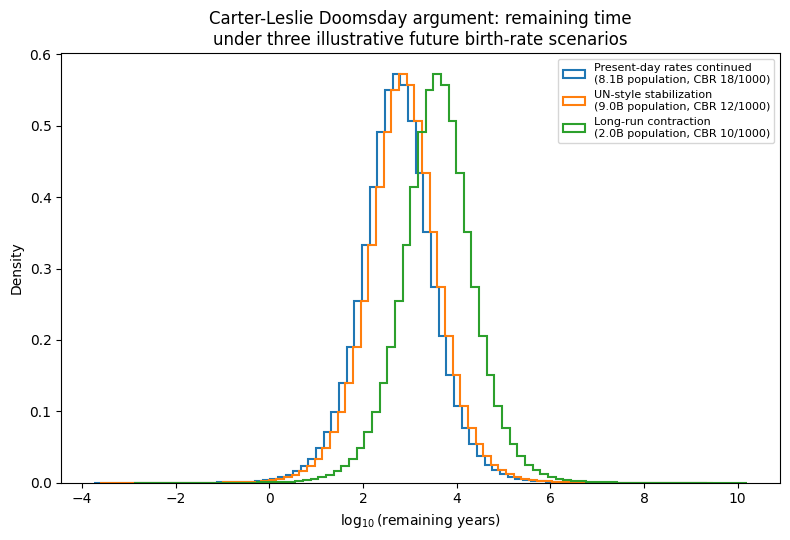

In [10]:
fig, ax = plt.subplots(figsize=(8, 5.5))
for name, rate in scenarios.items():
    yrs = remaining_births_draws / rate
    ax.hist(np.log10(yrs), bins=80, histtype="step", density=True, label=name, linewidth=1.5)
ax.set_xlabel(r"$\log_{10}$(remaining years)")
ax.set_ylabel("Density")
ax.set_title("Carter-Leslie Doomsday argument: remaining time\nunder three illustrative future birth-rate scenarios")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("fig3_doomsday_scenarios.png", dpi=150)
plt.show()


## 5. Synthesis: comparing the three approaches


In [11]:
synth_rows = [
    dict(method="A: Outside view (Kaplan-Meier)",  median_yr=residual_median_km(T0_PRIMARY)*1e6,
         lo_yr=np.nan, hi_yr=np.nan),
    dict(method="A: Outside view (Log-logistic)",  median_yr=residual_median_ll(T0_PRIMARY)*1e6,
         lo_yr=np.nan, hi_yr=np.nan),
    dict(method="B: Gott delta-t (time-based)",     median_yr=gott_interval(t_past_yr,0.001)[0],  # ~median at C->0
         lo_yr=gott_interval(t_past_yr,0.95)[0], hi_yr=gott_interval(t_past_yr,0.95)[1]),
]
for _, r in results_C.iterrows():
    synth_rows.append(dict(method=f"C: Carter-Leslie -- {r['scenario']}",
                            median_yr=r["median_remaining_yr"], lo_yr=r["lo95_yr"], hi_yr=r["hi95_yr"]))

synth_df = pd.DataFrame(synth_rows)
with pd.option_context("display.float_format", lambda x: f"{x:,.0f}"):
    print(synth_df.to_string(index=False))


                                                                        method  median_yr  lo_yr     hi_yr
                                                A: Outside view (Kaplan-Meier)  5,005,000    NaN       NaN
                                                A: Outside view (Log-logistic)  5,060,978    NaN       NaN
                                                  B: Gott delta-t (time-based)    194,610  5,000 7,605,000
C: Carter-Leslie -- Present-day rates continued (8.1B population, CBR 18/1000)        543     14    21,163
     C: Carter-Leslie -- UN-style stabilization (9.0B population, CBR 12/1000)        733     19    28,570
       C: Carter-Leslie -- Long-run contraction (2.0B population, CBR 10/1000)      3,961    102   154,276


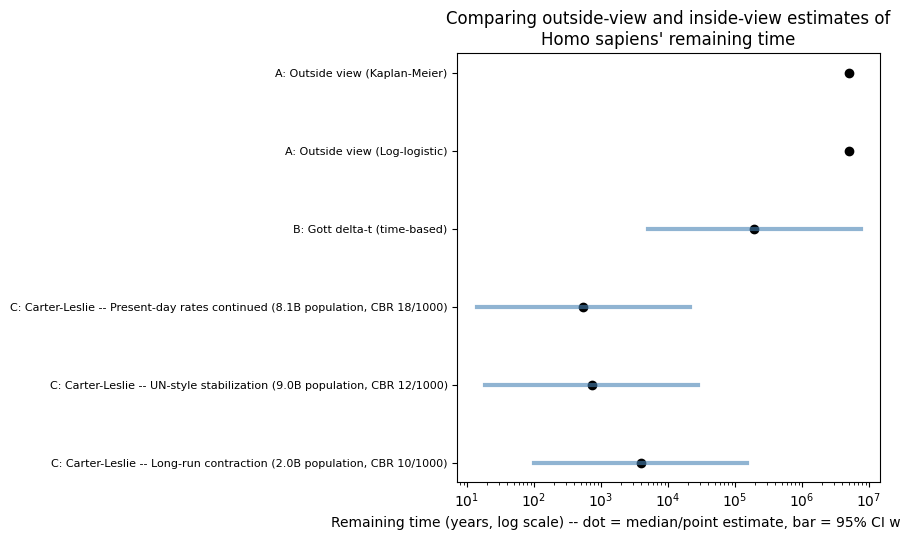

In [12]:
fig, ax = plt.subplots(figsize=(9, 5.5))
labels = synth_df["method"].tolist()
y_pos = np.arange(len(labels))
medians = synth_df["median_yr"].values
los = synth_df["lo_yr"].values
his = synth_df["hi_yr"].values

for i in range(len(labels)):
    ax.plot(medians[i], y_pos[i], "o", color="black")
    if not np.isnan(los[i]):
        ax.plot([los[i], his[i]], [y_pos[i], y_pos[i]], color="steelblue", linewidth=3, alpha=0.6)

ax.set_xscale("log")
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("Remaining time (years, log scale) -- dot = median/point estimate, bar = 95% CI where computed")
ax.set_title("Comparing outside-view and inside-view estimates of\nHomo sapiens' remaining time")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("fig4_synthesis_comparison.png", dpi=150)
plt.show()


The disagreement is large and structural, not a rounding difference:

- **Outside-view (A) and Gott's time-based argument (B) agree reasonably
  well** -- both land in the hundreds-of-thousands-to-low-millions-of-years
  range. This makes sense: both are, in different ways, extrapolating from
  "how much time has elapsed" without reference to population size or future
  demographic assumptions.
- **The Carter-Leslie argument (C) gives a dramatically shorter answer** --
  centuries to tens of thousands of years -- once combined with any
  plausible near-term human birth rate. This is because it reasons from
  *birth rank*, and the human population (and hence the birth rate) has
  grown so explosively in just the last few centuries that a very large
  share of all humans who will ever be born, under this argument's own logic,
  are pushed to have already been born -- compressing the remaining allotment
  into a short future *in time*, even though it may still be a large number
  of *people*.
- This is precisely the kind of disagreement the pros/cons discussion below
  flags as expected: (A)/(B) and (C) are not measuring the same thing, and
  nothing here should be read as one method "winning."


## 6. Pros and cons of this overall approach

*(Summarized from the fuller discussion earlier in this project thread.)*

**General, across all three methods**

- *Pro:* Grounding a forecast in either a real empirical reference class (A)
  or a well-defined self-sampling argument (B, C) is more disciplined than an
  unstructured guess, and gives a full distribution rather than a single
  number.
- *Con:* All three rest on a philosophically contested assumption -- that the
  present is not a special/privileged point in the relevant sequence (of
  species-durations, of elapsed time, or of birth order). Reasonable people,
  including specialists in anthropic reasoning, disagree about whether and
  how to apply this assumption (Bostrom 2002).

**Part A (outside view / mammalian species-duration priors)**

- *Pro:* Uses real, large-sample, censoring-corrected fossil data; the two
  independently-derived priors (nonparametric and parametric) agree closely,
  which is a modest reliability signal.
- *Con:* Reference-class mismatch is severe -- *H. sapiens* is an outlier on
  range, population size, genetic interconnectedness, and technological
  buffering relative to the mammal species that make up this dataset. The
  underlying data cannot resolve timescales below roughly one geological
  stage, so the "residual life" numbers should be read as very-long-run,
  order-of-magnitude statements, not near-term forecasts. Most real
  extinctions in this dataset were plausibly caused by exactly the kind of
  discrete environmental/competitive events this notebook's framing tries to
  exclude, so it's unclear the fitted hazard is even estimating the same
  "background" rate the question has in mind.

**Part B (Gott's time-based delta-t argument)**

- *Pro:* Extremely simple, requires no reference-class data at all, and is
  the most directly comparable in spirit to the outside-view answer.
- *Con:* Uses only elapsed time, discarding everything else we know
  (population dynamics, comparative biology); the self-sampling assumption
  it rests on is exactly the contested one Bostrom and others have
  critiqued.

**Part C (Carter-Leslie rank-based Doomsday argument)**

- *Pro:* Directly reuses this project's own rigorously-built population
  posterior rather than an external estimate.
- *Con:* The conversion from "remaining births" to "remaining time" requires
  a future birth-rate assumption that is, honestly, closer to a guess than a
  model -- and the answer is highly sensitive to that guess, as the three
  scenarios above demonstrate. The dramatic recent growth in human
  population also arguably makes this particular version of the argument
  behave unusually compared to how it would apply to a species with a more
  stable historical population trajectory.


## 7. Conclusions

1. Three structurally different, individually-defensible methods were
   applied to the same question and produced answers spanning roughly
   **four to five orders of magnitude** -- from centuries (Carter-Leslie
   under present-day birth rates) to several million years (outside-view
   species-duration residual life). This spread should be treated as the
   headline finding, not a nuisance to be averaged away.

2. Because *Homo sapiens*' elapsed existence (~195,000-315,000 years) is
   small relative to the bulk of the mammalian species-duration
   distributions fitted here, the outside-view forecast (Part A) is
   essentially unconditional -- conditioning on "having survived this long"
   barely moves the answer relative to just using the raw species-duration
   distribution.

3. The two inside-view arguments (B and C) formally both rest on a
   self-sampling assumption, yet they diverge sharply from each other once C
   is forced through a future-demographic-rate assumption. This suggests the
   birth-rank version of the Doomsday argument is considerably more sensitive
   to auxiliary assumptions, in this specific application, than the
   elapsed-time version.

4. None of these estimates should be treated as a forecast to act on. Their
   honest use is as a set of order-of-magnitude anchors and a demonstration
   of how much the answer depends on *which* structural assumption about
   "our position in history" is adopted -- which was, after all, the
   question this whole project thread set out to explore.

5. Natural next steps, in decreasing order of expected payoff per the
   pros/cons discussion above: (a) restricting Part A's reference class to
   large-bodied mammals or primates specifically, rather than all of
   Mammalia; (b) folding in NOW database data alongside PBDB, as previously
   deferred; (c) replacing the Normal approximation to the population
   posterior in Part C with the actual saved posterior draws from the hybrid
   model; and (d) exploring whether a population-genetics-based feasibility
   model for "transformation into a different species" (as opposed to a pure
   duration/hazard treatment) would meaningfully change Part A's picture.


## 8. References and bibliography

**This project's own prior work**
- `human_population_bayesian_model_v4.ipynb` -- Bayesian model of total
  humans ever born; source of the Part C population posterior summary
  statistics used here.
- `mammal_species_survival_v1.ipynb` -- full derivation, diagnostics, and
  data-quality discussion for the two mammalian species-duration priors used
  in Part A.

**Doomsday argument / anthropic reasoning**
- Gott, J.R. III (1993). "Implications of the Copernican principle for our
  future prospects." *Nature*, 363, 315-319. [Source of the time-based
  "delta-t" argument used in Part B.]
- Leslie, J. (1996). *The End of the World: The Science and Ethics of Human
  Extinction*. Routledge. [Development of the birth-rank Doomsday argument
  used in Part C.]
- Carter, B. (1983). "The anthropic principle and its implications for
  biological evolution." *Philosophical Transactions of the Royal Society A*,
  310(1512), 347-363. [Origin of the anthropic reasoning underlying the
  Doomsday argument.]
- Bostrom, N. (2002). *Anthropic Bias: Observation Selection Effects in
  Science and Philosophy*. Routledge. [Book-length treatment of the
  self-sampling assumption, the self-indication assumption, and their
  application to (and critiques of) the Doomsday argument; source of the
  "presumptuous philosopher" problem referenced in Section 1.]
- Ord, T. (2020). *The Precipice: Existential Risk and the Future of
  Humanity*. Hachette Books. [Referenced re: catastrophic/sudden risk, which
  this notebook explicitly excludes by the terms of the original question.]

**Paleobiological data and methods (carried forward from `mammal_species_survival_v1.ipynb`)**
- The Paleobiology Database (PBDB); `taxa/list` API endpoint,
  `base_name=Mammalia`.
- Kaplan, E.L. & Meier, P. (1958). "Nonparametric estimation from incomplete
  observations." *Journal of the American Statistical Association*, 53(282),
  457-481.
- Davidson-Pilon, C. (2019). "lifelines: survival analysis in Python."
  *Journal of Open Source Software*, 4(40), 1317.
- Van Valen, L. (1973). "A new evolutionary law." *Evolutionary Theory*, 1,
  1-30.
- Hublin, J.-J., et al. (2017). "New fossils from Jebel Irhoud, Morocco and
  the pan-African origin of Homo sapiens." *Nature*, 546, 289-292. [Source
  of the t0 = 315,000-year robustness check in Part A.]
